### Анализ коммерческого потенциала развлекательного контента и международных рынков на основе данных Netflix

#### Задачи ноутбука
 - провести анализ аудитории и характеристик контента;<br>
 - определить ключевые типы контента и их целевую аудиторию;<br>
 - выполнить анализ рынков и регионов по демографическим признакам;<br>
 - оценить коммерческую привлекательность стран и регионов;<br>
 - сформировать показатели рыночного потенциала;<br>
 - определить приоритетные рынки для продвижения контента;<br>

#### Загрузка обработанных данных

_Загрузить чистый датасет из ноутбука «01. Обработка данных»._

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("NetflixShows_clear.csv")
df.head(2)

,title,rating,ratingLevel,release year,user rating score,user rating size,sceneDesc,kids_audience_fit,youth_audience_fit,adult_audience_fit,...,rating_num,type_cat,audience_segment_cat,type_movie,type_tv,type_unknown,audience_segment_Adults,audience_segment_Family,audience_segment_Kids,audience_segment_Teens
0,White Chicks,PG-13,Parents strongly cautioned. May be inappropria...,2004,82.0,80,"crude and sexual humor, language and some drug...",0.2,1.0,0.6,...,4.1,movie,Teens,True,False,False,False,False,False,True
1,Lucky Number Slevin,R,Restricted. May be inappropriate for children ...,2006,NaN,82,"strong violence, sexual content and adult lang...",0.0,0.4,1.0,...,5.1,movie,Adults,True,False,False,True,False,False,False


### Часть 1. Анализ аудитории
В этой части я определяю где сидит основная аудитория и считаю суммарный user rating size по каждому рейтингу. Это позволяет определить, какие типы контента собирают наибольшую аудиторию и потенциальную массовую привлекательность.

Цвета подбирались на основе hex-кодов с использованием инструментов Coolors.co

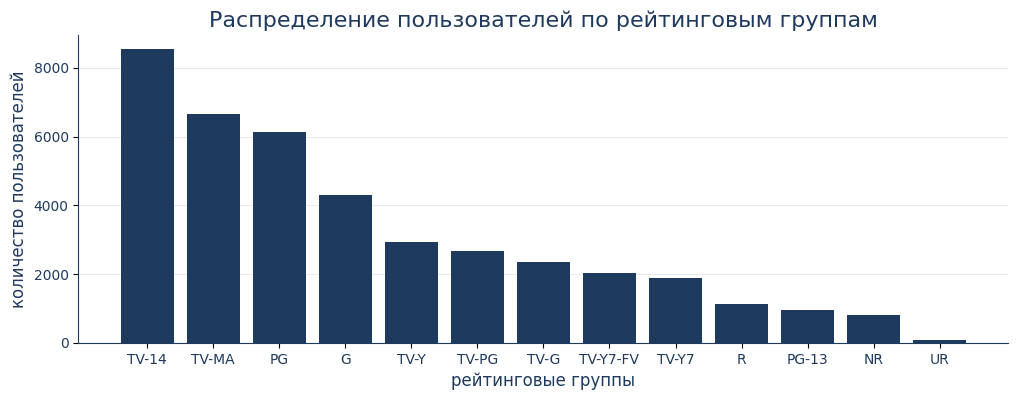

In [83]:
users = df.pivot_table(index = 'rating',values = 'user rating size',aggfunc='sum')
users_sorted = users.sort_values(by='user rating size', ascending=False)

plt.figure(figsize = (12,4))
bars = plt.bar(users_sorted.index, users_sorted['user rating size'], color ='#1f3a5f')

plt.title('Распределение пользователей по рейтинговым группам', fontsize = 16, color ='#1f3a5f' )
plt.xlabel ('рейтинговые группы',fontsize = 12, color ='#1f3a5f')
plt.ylabel ('количество пользователей',fontsize = 12, color ='#1f3a5f')
plt.yticks (range(0,8500, 2000), color ='#1f3a5f')
plt.xticks (color ='#1f3a5f')
plt.grid(axis='y', color='#1f3a5f', alpha=0.1)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#1f3a5f')
ax.spines['bottom'].set_color('#1f3a5f')

Наибольшей популярностью пользуется контент с рейтингом TV-14 (Parents strongly cautioned. May be unsuitable for children ages 14 and under.). Также значительное количество пользователей приходится на категории TV-MA (For mature audiences.  May not be suitable for children 17 and under.) и PG (Parental guidance suggested. May not be suitable for children.). В то же время узкоспециализированный контент (например, PG-13 и bloody war violence, language throughout and some sexual material.) привлекает значительно меньшее количество пользователей. 
Есть стабильный паттерн для G, TV-G, TV-Y, TV-Y7, TV-Y7-FV (Suitable for children ages 7 and older). 
UR и NR This movie has not been rated - для своего дальнейшего анализа яне использую эти данные.

Группирую рейтинги в возрастные сегменты и смотрю у кого больше охват.

In [84]:
audience = df.pivot_table(index = 'audience_segment_cat',values = 'user rating size',aggfunc='sum').sort_values(by='user rating size', ascending=False)

#audience = audience.drop(index = 'Unrated').reset_index()
audience['pct_rating size'] = round(audience['user rating size'] / sum(audience['user rating size']),2)

audience

,user rating size,pct_rating size
audience_segment_cat,,
Kids,13508,0.33
Teens,9504,0.23
Family,8798,0.22
Adults,8676,0.21


По результатам анализа можно сделать вывод, что наибольшую долю составляет детская аудитория (0–12 лет), на который приходится около 34% пользователей. Подростковая аудитория (13–17 лет) занимает около 24%, тогда как взрослая аудитория (18+) составляет примерно 22%. Семейная аудитория поддерживает тренды по детскому и подростковому еонтенту.

Полученные результаты показывают, что контент, ориентированный на детскую и подростковую аудиторию, обладает наибольшим потенциалом и может представлять повышенный интерес с точки зрения продвижения контента, ориентированного на эту аудиторию. В то же время взрослый контент, несмотря на меньшую долю аудитории, может иметь более высокую ценность в премиальных и нишевых сегментах рынка.

### Часть 2. Характеристики контента

Определяю позиционирование контента по аудитории и делаю оценку коммерческого потенциала контента для различных возрастных групп.

Создаю маппинг таблицу соответствия возрастных рейтингов Netflix и целевых аудиторий. Для каждого рейтинга определяю 3 показателя: Kids Audience Fit, Youth Audience Fit и Adult Audience Fit.

Каждому рейтингу присваиваю коэффициенты от 0 до 1, отражающие его привлекательность для соответствующей аудитории. Например, рейтинги G/TV-G получают высокий Kids Audience Fit (1), PG-13 и TV-14 — высокий Youth Audience Fit, а R и TV-MA — высокий Adult Audience Fit.

Коэффициенты задаю вручную (как допущение для целей учебного проекта) для преобразования категориальных рейтингов в числовые показатели, которые затем применяю для анализа контента и соответствия контента аудитории (Audience Fit).

Сегрегация была сделана в 1 буке
rating':['G','TV-G','TV-Y','TV-Y7','TV-Y7-FV',  'PG','TV-PG',  'PG-13','TV-14',  'R','TV-MA','NR','UR'],
    'audience_segment_cat':['Kids','Kids','Kids','Kids','Kids',  'Family','Family',  'Teens','Teens',  'Adults','Adults','Adults','Adults'],
    'kids_audience_fit':[1.0,1.0,1.0,1.0,1.0,  0.7,0.7,  0.2,0.2,  0.0,0.0,0.0,0.0],
    'youth_audience_fit':[0.2,0.2,0.2,0.2,0.2,  0.7,0.7,  1.0,1.0,  0.4,0.4,0.4,0.4],
    'adult_audience_fit':[0.2,0.2,0.2,0.2,0.2,  0.4,0.4,  0.6,0.6,  1.0,1.0,1.0,1.0]})

In [85]:

content = df
content.head(2)

,title,rating,ratingLevel,release year,user rating score,user rating size,sceneDesc,kids_audience_fit,youth_audience_fit,adult_audience_fit,...,rating_num,type_cat,audience_segment_cat,type_movie,type_tv,type_unknown,audience_segment_Adults,audience_segment_Family,audience_segment_Kids,audience_segment_Teens
0,White Chicks,PG-13,Parents strongly cautioned. May be inappropria...,2004,82.0,80,"crude and sexual humor, language and some drug...",0.2,1.0,0.6,...,4.1,movie,Teens,True,False,False,False,False,False,True
1,Lucky Number Slevin,R,Restricted. May be inappropriate for children ...,2006,NaN,82,"strong violence, sexual content and adult lang...",0.0,0.4,1.0,...,5.1,movie,Adults,True,False,False,True,False,False,False


### Часть 3. Анализ рынков
Провожу оценку международных рынков через сочетание демографического потенциала и экономической привлекательности, включая размер аудитории (демографические данные), возрастную структуру населения (демографические данные), уровень доходов (gdp данные).

In [86]:
population = pd.read_excel('UN_Population_2023.xlsx')
gdp = pd.read_excel('WB_gdp_2023.xlsx')
geo = pd.read_excel('Georgaphy_data.xlsx')
income_rate = pd.read_csv('lifeexpectancy-verbose.csv')

gdp = gdp[['country_code','gdp_per_capita_usd']]

youth_audience = ['20-24','25-29','30-34']

adult_columns = ['20-24','25-29','30-34','35-39','40-44','45-49','50-54','55-59','60-64','65-69','70-74','75-79','80-84','85-89','90-94']
population['0-12'] = round((population['0-4']+population['5-9']+population['10-14']/5*3),0)
population['13-17'] = round((population['10-14']/5*2 + population['15-19']/5*3),0)
population['18+'] = round((population['15-19']/5*2+population[adult_columns].sum(axis=1)),0)
population['young_adults'] = round((population[youth_audience].sum(axis=1) + population['15-19']/5*2),0)
population['total_population'] = population['0-12']+population['13-17']+population['18+']

population['0-12_pct'] = round(population['0-12']/population['total_population'],2)
population['13-17_pct'] = round(population['13-17']/population['total_population'],2)
population['18+_pct'] = round(population['18+']/population['total_population'],2)
population['young_adults_pct'] = round(population['young_adults']/population['total_population'],2)

population = population[['Region, subregion, country or area *', 'ISO3 Alpha-code', '0-12', '13-17', 'young_adults', '18+', 'total_population', '0-12_pct', '13-17_pct', 'young_adults_pct', '18+_pct']]
population = population.rename(columns={'Region, subregion, country or area *': 'country','ISO3 Alpha-code': 'country_code','0-12': 'age_group_0-12','13-17': 'age_group_13-17','18+': 'age_group_18+'})

population.head(1)

,country,country_code,age_group_0-12,age_group_13-17,young_adults,age_group_18+,total_population,0-12_pct,13-17_pct,young_adults_pct,18+_pct
0,Burundi,BDI,5432.0,1698.0,3531.0,6559.0,13689.0,0.4,0.12,0.26,0.48


In [87]:
income_rate = income_rate[['CountryCode', 'WorldBankIncomeGroupDisplay']]
income_rate = income_rate.rename(columns = {'WorldBankIncomeGroupDisplay': 'income_category', 'CountryCode': 'country_code'})
income_rate = income_rate.drop_duplicates(subset='country_code')
income_rate.head(1)

,country_code,income_category
0,NIC,Lower_middle_income


In [88]:
geo = geo[['alpha-3', 'region','sub-region']]
geo = geo.rename(columns = {'alpha-3': 'country_code'})
geo.head(1)

,country_code,region,sub-region
0,AFG,Asia,Southern Asia


In [89]:
regions= pd.merge(population, geo, on='country_code', how = 'left' ).merge(income_rate,on='country_code',how = 'left').merge(gdp, on ='country_code',how = 'left')
regions = regions.dropna(subset=['region', 'gdp_per_capita_usd'])

moda = regions.groupby('sub-region')['income_category'].apply(lambda x: x.mode()[0])
regions['income_category'] = regions['income_category'].fillna(regions['sub-region'].map(moda))

regions.head(2)

,country,country_code,age_group_0-12,age_group_13-17,young_adults,age_group_18+,total_population,0-12_pct,13-17_pct,young_adults_pct,18+_pct,region,sub-region,income_category,gdp_per_capita_usd
0,Burundi,BDI,5432.0,1698.0,3531.0,6559.0,13689.0,0.40,0.12,0.26,0.48,Africa,Sub-Saharan Africa,Low_income,250.627253
1,Comoros,COM,279.0,90.0,231.0,481.0,850.0,0.33,0.11,0.27,0.57,Africa,Sub-Saharan Africa,Low_income,1560.273785


Делаю анализ распределения населения стран, чтобы посмотреть на общую демографическую картину мира. Для корректного сравнения стран с сильно различающейся численностью населения использую логарифмическое преобразование данных. Построенная гистограмма позволяет оценить структуру мировых рынков и определить, какая часть стран относится к крупным, средним или малым по размеру населения рынкам.

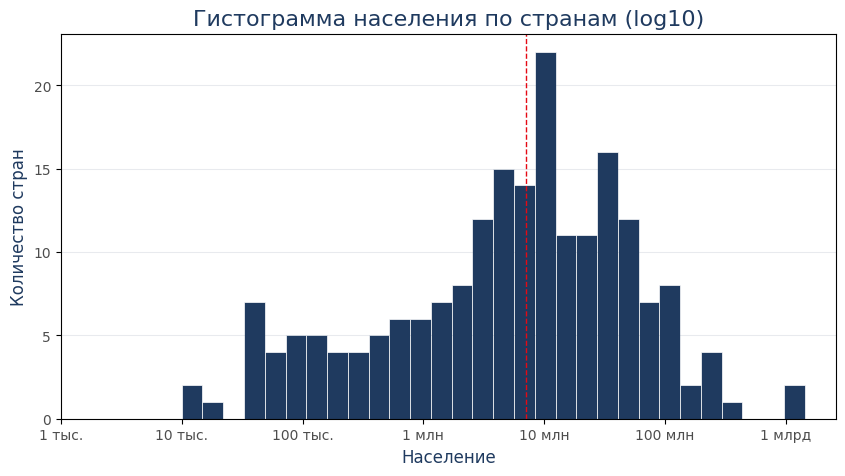

In [90]:
pop = regions['total_population']

log_population = np.log10(pop)

plt.figure(figsize=(10,5))

plt.hist(log_population, bins=30, color='#1f3a5f', edgecolor='white', linewidth=0.5)

plt.title('Гистограмма населения по странам (log10)', fontsize=16, color='#1f3a5f')
plt.xlabel('Население', fontsize=12, color='#1f3a5f')
plt.ylabel('Количество стран', fontsize=12, color='#1f3a5f')

xticks = [0, 1, 2, 3, 4, 5, 6]
xtick_labels = ['1 тыс.', '10 тыс.', '100 тыс.', '1 млн', '10 млн', '100 млн', '1 млрд']

plt.xticks(xticks, xtick_labels, color='#4d4d4d')
plt.yticks(color='#4d4d4d')

plt.grid(axis='y', alpha=0.1, color='#1f3a5f')

median = log_population.median()
plt.axvline(median, color='#E50914', linestyle='--', linewidth=1)
plt.show()

Гистограмма показывает, что распределение населения по странам является сильно асимметричным: большинство стран небольшие, в то время как Индия, Китай, США выглядят как выбросы (даже после логарифмирования). Медианное значение находится на уровне около 10 млн человек, что означает, что половина стран мира имеет население ниже данного уровня.

In [91]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

regions['population_log'] = np.log10(regions['total_population'])
regions['gdp_log'] = np.log10(regions['gdp_per_capita_usd'])

regions['population_score'] = scaler.fit_transform(regions[['population_log']])
regions['wealth_score'] = scaler.fit_transform(regions[['gdp_log']])

regions.head(1)

,country,country_code,age_group_0-12,age_group_13-17,young_adults,age_group_18+,total_population,0-12_pct,13-17_pct,young_adults_pct,18+_pct,region,sub-region,income_category,gdp_per_capita_usd,population_log,gdp_log,population_score,wealth_score
0,Burundi,BDI,5432.0,1698.0,3531.0,6559.0,13689.0,0.4,0.12,0.26,0.48,Africa,Sub-Saharan Africa,Low_income,250.627253,4.136372,2.399028,0.608096,0.0


Для каждого рынка считаю потенциал детского, молодежного и взрослого контента. Для расчета использую коэффициенты, учитывающие вес соответствующей возрастной группы, размер рынка и уровень благосостояния

In [92]:
regions['kids_market_score'] = (0.35 * regions['0-12_pct'] +  0.35 * regions['population_score'] + 0.3 * regions['wealth_score'])

regions['youth_market_score'] = (0.3 * regions['young_adults_pct'] + 0.3 * regions['population_score'] + 0.4 * regions['wealth_score'])

regions['adult_premium_score'] = (0.7 * regions['wealth_score'] + 0.3 * regions['18+_pct'])

regions = regions[['country','country_code','region', 'sub-region', '0-12_pct', 'young_adults_pct', '18+_pct', 'total_population','income_category', 
                   'wealth_score', 'population_score','kids_market_score', 'youth_market_score', 'adult_premium_score']]
regions.head(2)

,country,country_code,region,sub-region,0-12_pct,young_adults_pct,18+_pct,total_population,income_category,wealth_score,population_score,kids_market_score,youth_market_score,adult_premium_score
0,Burundi,BDI,Africa,Sub-Saharan Africa,0.40,0.26,0.48,13689.0,Low_income,0.000000,0.608096,0.352834,0.260429,0.144000
1,Comoros,COM,Africa,Sub-Saharan Africa,0.33,0.27,0.57,850.0,Low_income,0.263795,0.374086,0.325569,0.298744,0.355657


Строю графики для визуализации рыночной привлекательности на основе демографических и экономических показателей: общий потенциал рынка, потенциал детской аудитории, потенциал молодой аудитории, потенциал взрослого премиального сегмента.

Text(0, 0.5, 'Потенциал премиального взрослого рынка')

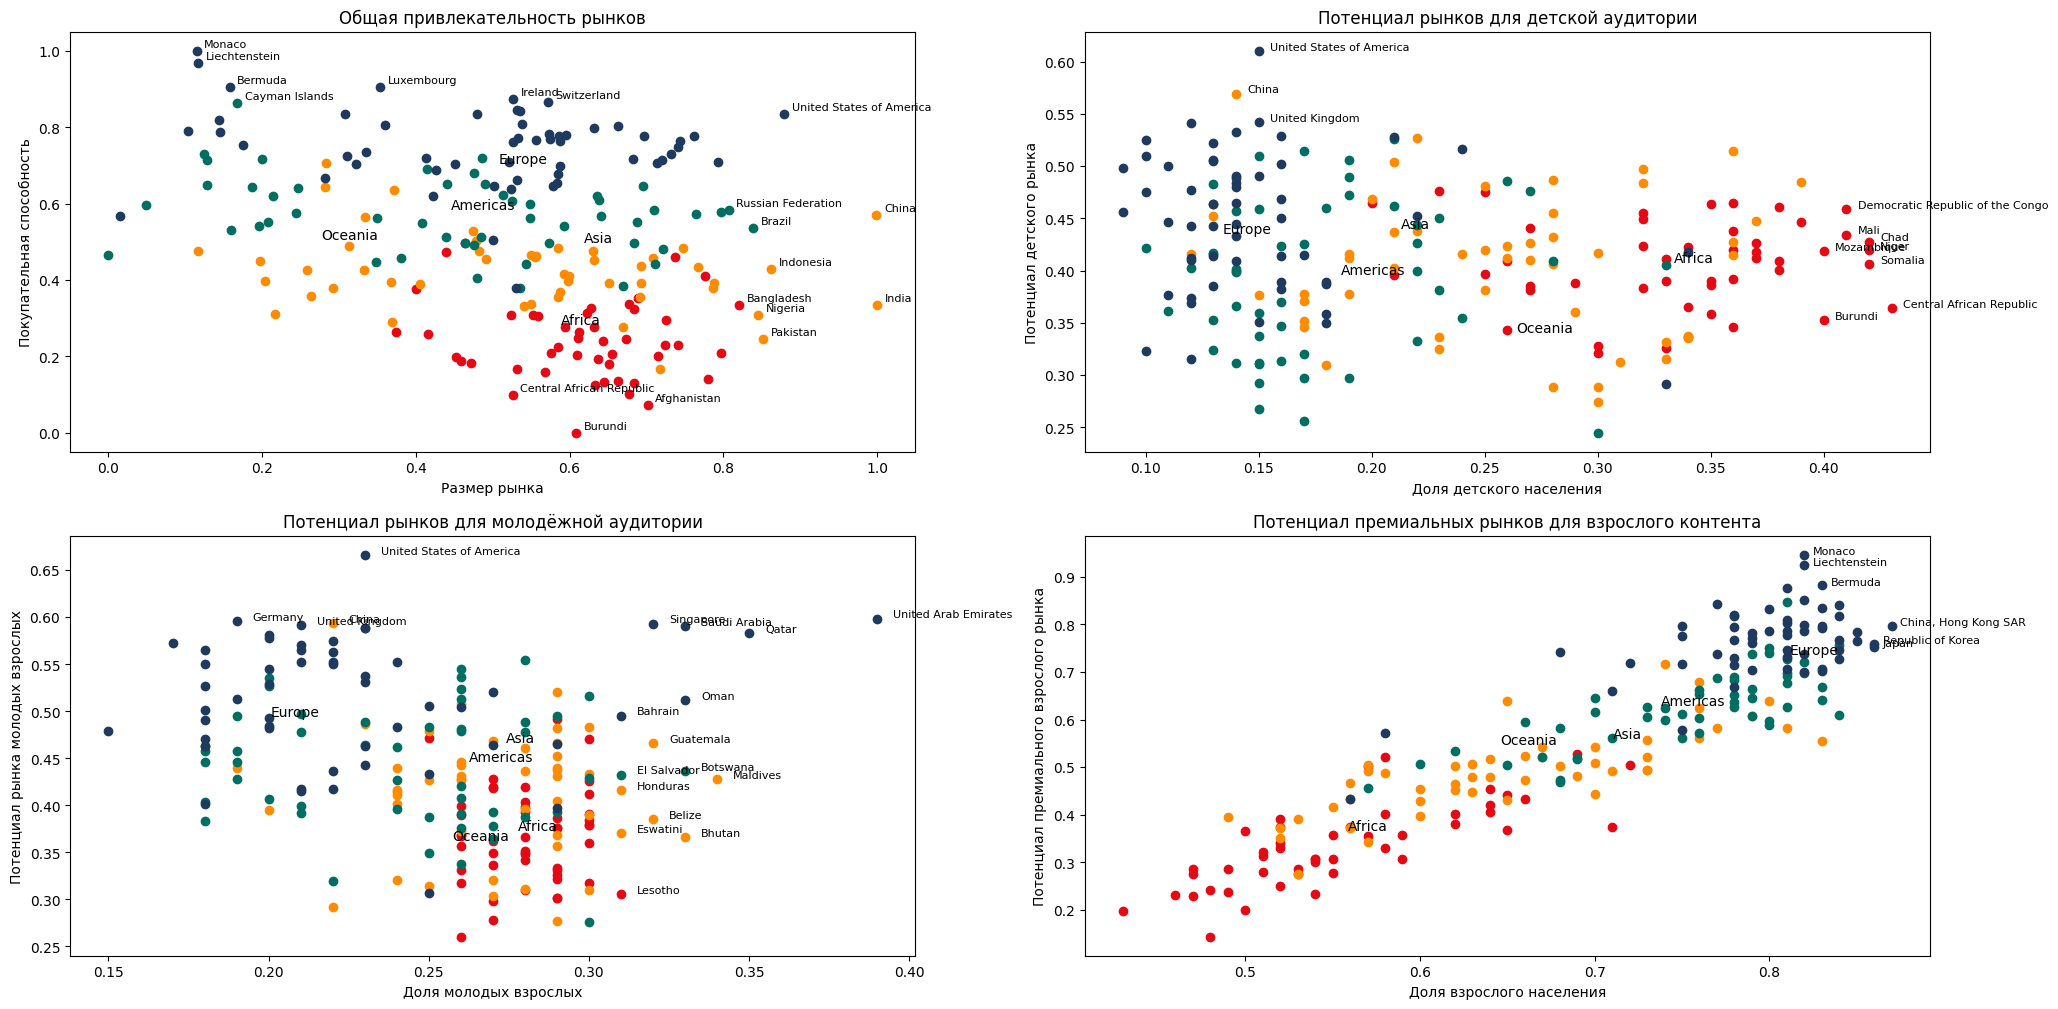

In [93]:
income_colors = {'Low_income': '#E50914', 'Lower_middle_income': "#FF8C00", 'Upper_middle_income': '#006F62','High_income': '#1f3a5f'}
fig, axes = plt.subplots(2, 2, figsize=(24, 12))

ax = axes[0,0]

for income_cat, color in income_colors.items():
    data = regions[regions['income_category'] == income_cat]
    ax.scatter(data['population_score'],data['wealth_score'], color=color, label=income_cat)

region_labels = regions.groupby('region').agg({'population_score':'mean','wealth_score':'mean',}).reset_index()

for _, row in region_labels.iterrows():
    ax.text(row['population_score'],row['wealth_score'],row['region'],fontsize=10)
   
key_markets = regions[(regions['population_score'] >= 0.8) | (regions['wealth_score'] >= 0.85) | (regions['wealth_score'] <= 0.1)]

for _, row in key_markets.iterrows():
    ax.text(row['population_score'] + 0.01,row['wealth_score'] + 0.01, row['country'], fontsize=8)

ax.set_title('Общая привлекательность рынков')
ax.set_xlabel('Размер рынка')
ax.set_ylabel('Покупательная способность')


ax = axes[0,1]

for income_cat, color in income_colors.items():
    data = regions[regions['income_category'] == income_cat]
    ax.scatter(data['0-12_pct'], data['kids_market_score'],color=color, label=income_cat)

region_labels = regions.groupby('region').agg({'0-12_pct':'mean', 'kids_market_score':'mean'}).reset_index()

for _, row in region_labels.iterrows():
    ax.text(row['0-12_pct'],row['kids_market_score'],row['region'],fontsize=10)

key_markets = regions[(regions['kids_market_score'] >= regions['kids_market_score'].quantile(0.99)) |
                    (regions['0-12_pct'] >= regions['0-12_pct'].quantile(0.97))]

for _, row in key_markets.iterrows():
    ax.text(row['0-12_pct'] + 0.005, row['kids_market_score'] + 0.001, row['country'], fontsize=8)

ax.set_title('Потенциал рынков для детской аудитории')
ax.set_xlabel('Доля детского населения')
ax.set_ylabel('Потенциал детского рынка')


ax = axes[1,0]

for income_cat, color in income_colors.items():
    data = regions[regions['income_category'] == income_cat]
    ax.scatter(data['young_adults_pct'], data['youth_market_score'],color=color, label=income_cat)

region_labels = regions.groupby('region').agg({'young_adults_pct':'mean', 'youth_market_score':'mean'}).reset_index()

for _, row in region_labels.iterrows():
    ax.text(row['young_adults_pct'],row['youth_market_score'],row['region'],fontsize=10)
 
key_markets = regions[(regions['youth_market_score'] >= regions['youth_market_score'].quantile(0.97)) |
                    (regions['young_adults_pct'] >= regions['young_adults_pct'].quantile(0.95))]

for _, row in key_markets.iterrows():
    ax.text(row['young_adults_pct'] + 0.005, row['youth_market_score'] + 0.001, row['country'], fontsize=8)

ax.set_title('Потенциал рынков для молодёжной аудитории')
ax.set_xlabel('Доля молодых взрослых')
ax.set_ylabel('Потенциал рынка молодых взрослых')


ax = axes[1,1]

for income_cat, color in income_colors.items():
    data = regions[regions['income_category'] == income_cat]
    ax.scatter(data['18+_pct'], data['adult_premium_score'],color=color, label=income_cat)

region_labels = regions.groupby('region').agg({'18+_pct':'mean', 'adult_premium_score':'mean'}).reset_index()

for _, row in region_labels.iterrows():
    ax.text(row['18+_pct'],row['adult_premium_score'],row['region'],fontsize=10)

key_markets = regions[(regions['adult_premium_score'] >= regions['adult_premium_score'].quantile(0.99)) |
                    (regions['18+_pct'] >= regions['18+_pct'].quantile(0.99))]

for _, row in key_markets.iterrows():
    ax.text(row['18+_pct'] + 0.005, row['adult_premium_score'] + 0.001, row['country'], fontsize=8)

ax.set_title('Потенциал премиальных рынков для взрослого контента')
ax.set_xlabel('Доля взрослого населения')
ax.set_ylabel('Потенциал премиального взрослого рынка')

**График общей привлекательности рынков** демонстрирует различия рынков по уровню покупательской способности и масштабу аудитории. Рынки Северной Америки и Западной Европы отражают высокий уровень доходов, тогда как крупнейшие развивающиеся рынки Азии обладают существенно более масштабной аудиторией. Небольшие обеспеченные экономики формируют премиальные нишевые рынки с высокой покупательской способностью, но ограниченным потенциалом массового охвата.
**График потенциала детского рынка**  показывает наибольший потенциал для детского и семейного контента в крупных странах Азии, Латинской Америки и части Африки. Индия, Китай, Индонезия и Бразилия сочетают высокую долю детского населения, что делает их особенно привлекательными для развития семейных развлекательных контентов.
**График потенциала молодёжного рынка** демонстрирует наиболее высокий потенциал в странах Азии и Ближнего Востока. США, Китай, Индия, Саудовская Аравия и ОАЭ сочетают высокую долю молодой аудитории с масштабируемой развлекательной инфраструктурой, что делает их наиболее перспективными для развития развлекательного контента, с фокусом на фанатские сообщества.
**График потенциала взрослого премиального рынка** показывает потенциал для премиального и взрослого контента в развитых странах Европы и Северной Америки с высоким уровнем доходов населения.

#### Классифицирование рынков
Выполняем классификацию международных рынков развлекательного контента на:
 - Премиальные зрелые рынки - развитые страны с высоким уровнем доходов и покупательной способность
 - Рынки масштабируемого роста - крупные растущие рынки с высокой концентрацией молодой аудитории
 - Рынки с ограниченным коммерческим потенциалом - рынки с низким потенциалом масштабирования и монетизации

In [94]:
regions['premium_market_score'] = regions['adult_premium_score']
regions['growth_market_score'] = (0.4 * regions['youth_market_score'] + 0.35 * regions['kids_market_score'] + 0.25 * regions['wealth_score'])

conditions = [regions['premium_market_score'] >= 0.8,  regions['growth_market_score'] >= 0.45]

choices = ['Premium Mature Markets','Scalable Growth Markets']

regions['market_archetype_final'] = np.select(conditions,choices,default='Limited Commercial Potential')

market_archetypes = (regions[['country','region', 'income_category', '0-12_pct','young_adults_pct','18+_pct','population_score', 'wealth_score', 'kids_market_score', 'youth_market_score', 
'adult_premium_score', 'growth_market_score', 'premium_market_score','market_archetype_final']].sort_values(['market_archetype_final', 'growth_market_score', 'premium_market_score'],ascending=[True, False, False]))

market_archetypes.head(2)

,country,region,income_category,0-12_pct,young_adults_pct,18+_pct,population_score,wealth_score,kids_market_score,youth_market_score,adult_premium_score,growth_market_score,premium_market_score,market_archetype_final
230,French Polynesia,Oceania,Lower_middle_income,0.17,0.24,0.76,0.281182,0.644421,0.351240,0.414123,0.679094,0.449688,0.679094,Limited Commercial Potential
185,Turks and Caicos Islands,Americas,Upper_middle_income,0.15,0.24,0.80,0.128499,0.714429,0.311803,0.396321,0.740100,0.446267,0.740100,Limited Commercial Potential


### Часть 4. Анализ соответствия контента и рынков 
Соединяю характеристики контента и характеристики рынков в единую таблицу, чтобы оценить, насколько каждый фильм или сериал подходит каждому рынку.

У content/фильма нет “страны” как ключа. Использую искусственный ключ для соединения каждой строки контента с каждой строкой маркета, те создаем все возможные пары (фильм × рынок), чтобы потом посчитать fit score, насколько аудитория фильма совпадает с характеристиками рынка.


In [95]:
content['key'] = 1
market_archetypes['key'] = 1
content = content[['title','rating','user rating size','audience_segment_cat','kids_audience_fit','youth_audience_fit','adult_audience_fit', 'key']]
markets = market_archetypes[['country','region','income_category','wealth_score','kids_market_score','youth_market_score','adult_premium_score','market_archetype_final','key']]
content_market_fit = (pd.merge(content, market_archetypes, on='key', how='inner').drop('key', axis=1))
content_market_fit.head(2)

,title,rating,user rating size,audience_segment_cat,kids_audience_fit,youth_audience_fit,adult_audience_fit,country,region,income_category,...,young_adults_pct,18+_pct,population_score,wealth_score,kids_market_score,youth_market_score,adult_premium_score,growth_market_score,premium_market_score,market_archetype_final
0,White Chicks,PG-13,80,Teens,0.2,1.0,0.6,French Polynesia,Oceania,Lower_middle_income,...,0.24,0.76,0.281182,0.644421,0.351240,0.414123,0.679094,0.449688,0.679094,Limited Commercial Potential
1,White Chicks,PG-13,80,Teens,0.2,1.0,0.6,Turks and Caicos Islands,Americas,Upper_middle_income,...,0.24,0.80,0.128499,0.714429,0.311803,0.396321,0.740100,0.446267,0.740100,Limited Commercial Potential


Определяю Fit Score для каждой пары 'контент–рынок'. Как рабочее допущение -коэффициенты заданы вручную. Мы предполагаем, что молодёжный сегмент имеет немного больший вес, потому что подростки чаще формируют фанатские сообщества и долгосрочный спрос. Детский и взрослый сегменты имеют равный вес, так как оба важны для монетизации, один через мерч, другой через подписку. 

In [96]:
content_market_fit['kids_fit'] = (content_market_fit['kids_audience_fit'] *content_market_fit['kids_market_score'])
content_market_fit['youth_fit'] = (content_market_fit['youth_audience_fit'] * content_market_fit['youth_market_score'])
content_market_fit['adult_fit'] = (content_market_fit['adult_audience_fit'] * content_market_fit['adult_premium_score'])


content_market_fit['commercial_fit'] = (0.3 * content_market_fit['kids_fit'] + 0.4 * content_market_fit['youth_fit'] + 0.3 * content_market_fit['adult_fit'])

result = (content_market_fit[['title','rating','audience_segment_cat', 'user rating size','country','region','income_category','market_archetype_final',
                              'kids_fit','youth_fit','adult_fit','commercial_fit']].sort_values('commercial_fit', ascending=False))

result.head(2)

,title,rating,audience_segment_cat,user rating size,country,region,income_category,market_archetype_final,kids_fit,youth_fit,adult_fit,commercial_fit
49958,Gotham,TV-14,Teens,80,United States of America,Americas,High_income,Premium Mature Markets,0.122068,0.666235,0.490515,0.450269
45335,The Returned,TV-14,Teens,82,United States of America,Americas,High_income,Premium Mature Markets,0.122068,0.666235,0.490515,0.450269


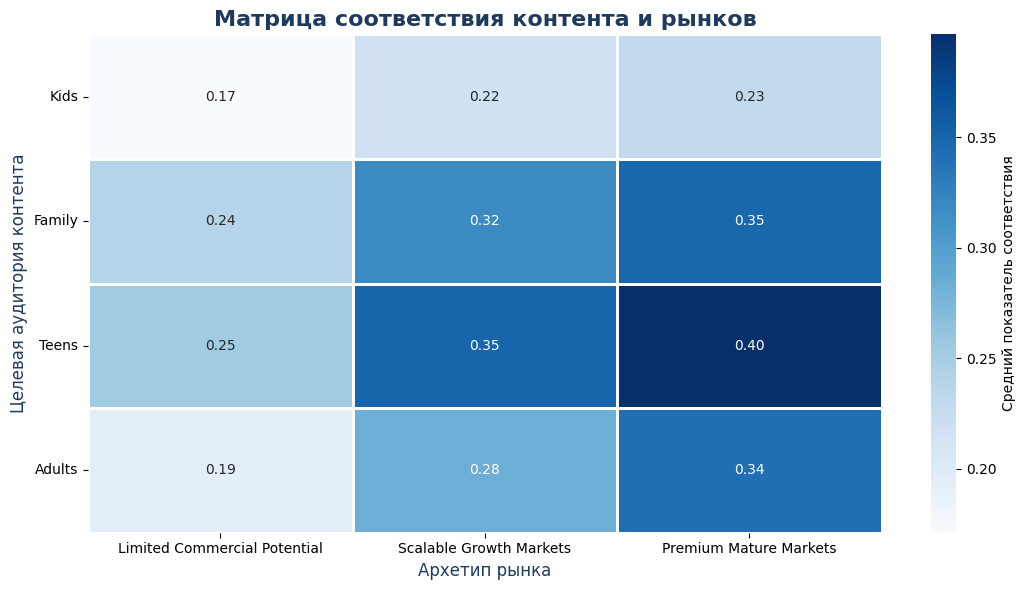

In [97]:
fit_matrix = (result.groupby(['audience_segment_cat', 'market_archetype_final'], as_index=False).agg(avg_commercial_fit=('commercial_fit', 'mean')))
fit_pivot = fit_matrix.pivot(index='audience_segment_cat',columns='market_archetype_final',values='avg_commercial_fit')

audience_order = ['Kids', 'Family', 'Teens', 'Adults']
market_order = ['Limited Commercial Potential','Scalable Growth Markets','Premium Mature Markets']

fit_pivot = fit_pivot.reindex(index=audience_order,columns=market_order)

plt.figure(figsize=(11, 6))

sns.heatmap(fit_pivot,annot=True,cmap='Blues',linewidths=1,fmt='.2f',cbar_kws={'label': 'Средний показатель соответствия'})
plt.title('Матрица соответствия контента и рынков', fontsize=16,fontweight='bold',color='#1f3a5f')
plt.xlabel('Архетип рынка', fontsize=12, color='#1f3a5f')
plt.ylabel('Целевая аудитория контента', fontsize=12, color='#1f3a5f')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Построенный фреймворк Content-Market Fit дает представление какие типы контента обладают наибольшим потенциалом и на каких ранках. Анализ показывает, что коммерческий потенциал контента зависит не только от качества самого контента, но и от соответствия демографическим и экономическим характеристикам рынка.

**Детский контент / Kids Content** показывает более низкий коммерческий потенциал, скорее всего потому что семейный сегмент его перекрывает (здесь достаточно спорный вопрос особенно для растущих рынков). Наиболее перспективными для данного сегмента остаются растущие и развитые рынки.

**Семейный контент/Family Content** показывает высокую универсальность и интересен тем, что не привязан к конкретному типу рынка — его берут и в США, и в Бразилии, и в Китае. Поэтому именно он чаще всего становится основой для мерча и франшиз.

**Подростковый контент/Teen Content** демонстрирует наивысший коммерческий потенциал практически на всех типах рынков. Наибольшее соответствие наблюдается на премиальных и рынках масштабируемого роста. Подростковый контент-это то, что "взрывается" в соцсетях. Именно поэтому он лучше всего работает там где много молодёжи — Индия, Китай, Бразилия, где один успешный тайтл может вырасти в игру, мерч и целую вселенную.

**Взрослая аудитория/Adult Content** наиболее эффективен на премиальных зрелых рынках с высокой покупательскоой способностью населения. Монако, Швейцария, США -здесь взрослая аудитория с высоким доходом, которая платит за качественный контент, а не ищет его бесплатно.

Разработанный фреймворк Content-Market Fit показывает, что успешная международная стратегия Netflix должна учитывать не только популярность контента, но и соответствие возрастной структуре аудитории, масштаба рынка и уровня покупательской способности населения. Результаты анализа позволяют определить, какой тип контента обладает наибольшим коммерческим потенциалом на каждом типе международного рынка и где вероятность успешного масштабирования контента наиболе высока.